<a href="https://colab.research.google.com/github/BishalDas1010/Cab-ride-price-prediction/blob/main/Cab_ride_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print("hello")

hello


Data fatch from Kaggle

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ravi72munde/uber-lyft-cab-prices")

print("Path to dataset files:", path)

100%|██████████| 73.5M/73.5M [00:02<00:00, 28.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ravi72munde/uber-lyft-cab-prices/versions/4


In [4]:
import pandas as pd
import os

# List files in the downloaded directory
files_in_path = os.listdir(path)

# Filter for CSV files
csv_files = [f for f in files_in_path if f.endswith('.csv')]

# Assuming there's at least one CSV file and we want the first one
if csv_files:
    csv_file_name = csv_files[0]
    full_csv_path = os.path.join(path, csv_file_name)
    df = pd.read_csv(full_csv_path)
    print(f"Successfully loaded: {full_csv_path}")
else:
    print(f"No CSV files found in the directory: {path}")
    df = None # Or handle the error as appropriate

Successfully loaded: /root/.cache/kagglehub/datasets/ravi72munde/uber-lyft-cab-prices/versions/4/cab_rides.csv


In [10]:
df.shape

(693071, 10)

In [12]:
df.columns.to_list()

['distance',
 'cab_type',
 'time_stamp',
 'destination',
 'source',
 'price',
 'surge_multiplier',
 'id',
 'product_id',
 'name']

In [5]:
df.head()

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.0,1.0,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.0,1.0,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft
3,0.44,Lyft,1543553582749,North Station,Haymarket Square,26.0,1.0,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL
4,0.44,Lyft,1543463360223,North Station,Haymarket Square,9.0,1.0,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL


In [16]:
#not missing  values
df.notna().sum().sort_values(ascending=False).head(20)

,0
distance,693071
cab_type,693071
time_stamp,693071
destination,693071
source,693071
surge_multiplier,693071
product_id,693071
id,693071
name,693071
price,637976


In [ ]:
#missing values nan,None,Nan ->True

In [19]:
df.isna().sum().sort_values(ascending=True).head(20)

,0
distance,0
cab_type,0
time_stamp,0
destination,0
source,0
surge_multiplier,0
id,0
product_id,0
name,0
price,55095


# Describe Function

## 🔹 Definitions
- **Mean → Average value**
- **Standard Deviation (std) → tells whether data is close to the average or spread far from it**

---

## Formula

### Mean
$$
\text{Mean} = \frac{\sum x}{n}
$$

### Standard Deviation (concept)
$$
\text{Std measures how much values deviate from the mean}
$$

---

##  Example 1 (Low Std)

**Data:**
```python
[10, 11, 12]

In [20]:
df.describe(include='all')

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
count,693071.000000,693071,6.930710e+05,693071,693071,637976.000000,693071.000000,693071,693071,693071
unique,NaN,2,NaN,12,12,NaN,NaN,693071,13,13
top,NaN,Uber,NaN,Financial District,Financial District,NaN,NaN,e7fdc087-fe86-40a5-a3c3-3b2a8badcbda,6f72dfc5-27f1-42e8-84db-ccc7a75f6969,UberXL
freq,NaN,385663,NaN,58851,58857,NaN,NaN,1,55096,55096
mean,2.189430,NaN,1.544046e+12,NaN,NaN,16.545125,1.013870,NaN,NaN,NaN
std,1.138937,NaN,6.891925e+08,NaN,NaN,9.324359,0.091641,NaN,NaN,NaN
min,0.020000,NaN,1.543204e+12,NaN,NaN,2.500000,1.000000,NaN,NaN,NaN
25%,1.280000,NaN,1.543444e+12,NaN,NaN,9.000000,1.000000,NaN,NaN,NaN
50%,2.160000,NaN,1.543737e+12,NaN,NaN,13.500000,1.000000,NaN,NaN,NaN
75%,2.920000,NaN,1.544828e+12,NaN,NaN,22.500000,1.000000,NaN,NaN,NaN


# EDA (visual + nnumeric )

In [24]:
df['datetime'] =pd.to_datetime( df['time_stamp'],unit="ms")

In [25]:
df["hour"] = df["datetime"].dt.hour

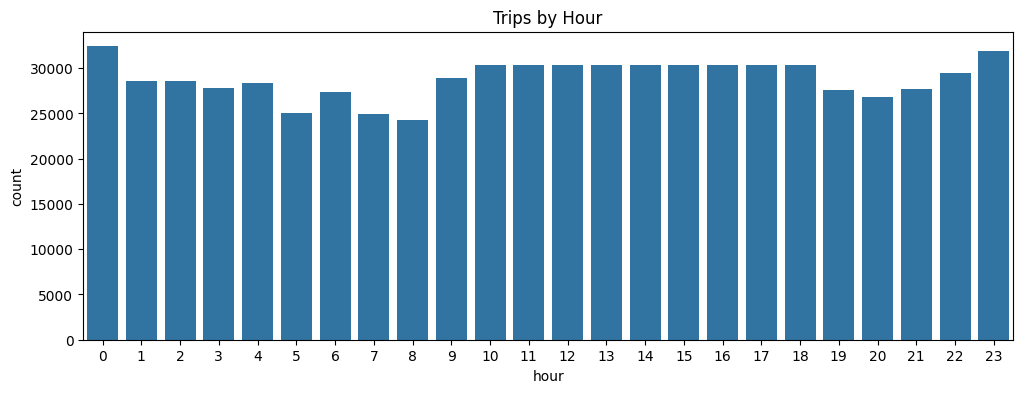

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,4))
sns.countplot(x=df["hour"])
plt.title("Trips by Hour")
plt.show()